# Neuro-Symbolic Architectures for Long-Horizon Egocentric Perception
## A Forward-Backward State Space Approach to Dietary Monitoring

### 1. Introduction: The Contextual Bottleneck
This notebook implements a prototype of the **"Forward-Backward"** architecture designed to solve the "context saturation" problem in long-horizon egocentric video analysis.

Standard VideoLLMs (like VideoLLaVA) suffer from quadratic complexity and fill their context windows with "useless" background information (walking, sitting). This architecture splits the problem into two distinct systems, mimicking human cognition:

1.  **System 1 (The Forward Pass)**: A fast, online perception engine.
    *   **Encoder**: Frozen **V-JEPA2** (ViT-H/16) for robust, physics-aware feature extraction.
    *   **State Tracker**: A Causal State Space Model (simulating **VideoMamba**) that predicts the next latent state.
    *   **Event Segmentation**: Detects **"Surprise" (Prediction Error)** to identify event boundaries (e.g., the moment a hand grabs food).

2.  **System 2 (The Backward Pass)**: A slow, deliberative reasoning engine.
    *   **Retrieval**: Fetches specific "Surprise Events" from a hierarchical index.
    *   **Tool Use**: Applies geometric tools (**FoodTrack**: Hand Mesh + Object Volumetry) to these specific frames to estimate calories.

### 2. Theoretical Framework
*   **Event Segmentation Theory (EST)**: Humans segment continuous experience into events based on transient spikes in prediction error.
*   **Predictive Coding**: We use the error signal $\| z_t - \hat{z}_t \|_2$ as a proxy for semantic change.

---
**Current Status**: This prototype runs on a single clip from **EPIC-KITCHENS-100** to demonstrate the signal processing pipeline.

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoVideoProcessor, AutoModel
import os
import torch.nn as nn
from torchcodec.decoders import VideoDecoder
from datasets import load_dataset

# Check for CUDA
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


In [6]:
# Load V-JEPA2 model and processor
hf_repo = "facebook/vjepa2-vitl-fpc64-256"
print(f"Loading model from {hf_repo}...")

try:
    processor = AutoVideoProcessor.from_pretrained(hf_repo)
    model = AutoModel.from_pretrained(hf_repo).to(DEVICE)
    model.eval() # Set to evaluation mode (Frozen)
    print("Model loaded successfully.")
except Exception as e:
    print(f"Error loading model: {e}")
    print("Please ensure you have internet access and transformers installed.")

Loading model from facebook/vjepa2-vitl-fpc64-256...
Model loaded successfully.


In [7]:
# Load video and extract features (64 frames = 16 seconds)
try:
    print("Using cached EPIC-KITCHENS-100 dataset from local cache...")
    
    # Direct path to cached dataset
    dataset_cache_path = os.path.expanduser("~/.cache/huggingface/hub/datasets--awsaf49--epic_kitchens_100/snapshots/c5e573b9295c06bd6d14bd5a9b9c7b178f00d7b1")
    
    # Use the first video from P01 as a sample
    video_path = os.path.join(dataset_cache_path, "P01/videos/P01_101.MP4")
    
    if not os.path.exists(video_path):
        raise FileNotFoundError(f"Video file not found: {video_path}")
    
    print(f"Loading video: {video_path}")
    
    # Target settings
    TARGET_FPS = 4
    NUM_FRAMES = 64  # V-JEPA requires 64 frames (16 seconds at 4 FPS)
    
    # Load video using torchcodec
    vr = VideoDecoder(video_path)
    
    # Get video metadata
    original_fps = getattr(vr.metadata, 'average_fps', 60.0)
    if original_fps is None: 
        original_fps = 60.0
    
    total_frames = vr.metadata.num_frames if hasattr(vr.metadata, 'num_frames') else 10000
    
    # Calculate frame sampling stride to achieve TARGET_FPS
    sampling_stride = max(1, int(round(original_fps / TARGET_FPS)))
    print(f"Video: {total_frames} frames @ {original_fps:.2f} FPS")
    print(f"Sampling: Every {sampling_stride} frames → {TARGET_FPS} FPS effective")
    
    # Select 64 frames from the beginning of the video
    frame_idx = np.arange(NUM_FRAMES) * sampling_stride
    frame_idx = frame_idx[frame_idx < total_frames]
    
    if len(frame_idx) < NUM_FRAMES:
        print(f"Warning: Only {len(frame_idx)} frames available, padding...")
        # Repeat last frame to reach 64
        padding_needed = NUM_FRAMES - len(frame_idx)
        last_frame = frame_idx[-1] if len(frame_idx) > 0 else 0
        frame_idx = np.concatenate([frame_idx, np.full(padding_needed, last_frame)])
    
    print(f"Loading {NUM_FRAMES} frames (16 seconds at {TARGET_FPS} FPS)...")
    
    # Load frames
    video_data = vr.get_frames_at(indices=frame_idx.tolist()).data
    
    # Process with V-JEPA processor
    inputs = processor(list(video_data), return_tensors="pt")
    inputs = {k: v.to(DEVICE) for k, v in inputs.items() if isinstance(v, torch.Tensor)}
    
    # Extract features
    with torch.no_grad():
        if hasattr(model, "get_vision_features"):
            try:
                outputs = model.get_vision_features(**inputs)
            except TypeError:
                if 'pixel_values' in inputs:
                    outputs = model.get_vision_features(inputs['pixel_values'])
                else:
                    raise
        else:
            outputs = model(**inputs)
            if hasattr(outputs, 'last_hidden_state'):
                outputs = outputs.last_hidden_state
    
    # Handle output format
    if isinstance(outputs, torch.Tensor):
        latents = outputs.detach().cpu().numpy()
    else:
        latents = outputs.last_hidden_state.detach().cpu().numpy()
    
    # Reshape to (Frames, Patches, Dim) and pool over patches
    actual_frames = inputs['pixel_values'].shape[1] if 'pixel_values' in inputs else NUM_FRAMES
    patches_per_frame = latents.shape[1] // actual_frames
    feature_dim = latents.shape[2]
    
    frame_features = latents[0].reshape(actual_frames, patches_per_frame, feature_dim).mean(axis=1)
    
    print(f"\n✓ Extracted features from {len(frame_features)} frames")
    print(f"  Feature shape: {frame_features.shape}")
    print(f"  Frame indices: {frame_idx[0]} → {frame_idx[-1]}\n")
    
    # Store for later use
    global_frame_indices = frame_idx
    window_metadata = [{'window_idx': 0, 'start_frame_global': int(frame_idx[0]), 
                       'end_frame_global': int(frame_idx[-1]), 'num_frames': NUM_FRAMES}]

except Exception as e:
    print(f"Error loading dataset: {e}")
    import traceback
    traceback.print_exc()
    print("Falling back to dummy data.")
    
    # Fallback
    frame_features = np.random.randn(64, 1024)
    global_frame_indices = np.arange(64)
    window_metadata = [{'window_idx': 0, 'start_frame_global': 0, 'end_frame_global': 63, 'num_frames': 64}]


Using cached EPIC-KITCHENS-100 dataset from local cache...
Loading video: /home/jefferyfan/.cache/huggingface/hub/datasets--awsaf49--epic_kitchens_100/snapshots/c5e573b9295c06bd6d14bd5a9b9c7b178f00d7b1/P01/videos/P01_101.MP4
Video: 91573 frames @ 50.00 FPS
Sampling: Every 12 frames → 4 FPS effective
Loading 64 frames (16 seconds at 4 FPS)...

✓ Extracted features from 64 frames
  Feature shape: (64, 1024)
  Frame indices: 0 → 756



In [8]:
import sys
import importlib
import os

# Add the GatedDeltaNet repository to the path
# We use GatedDeltaNet (a Linear Attention / RNN variant) as our implementation 
# of the "Causal State Space Predictor" (conceptually similar to Mamba).
sys.path.append(os.path.abspath("../GatedDeltaNet"))

try:
    import lit_gpt
    import lit_gpt.gated_delta_net
    if 'lit_gpt.gated_delta_net' in sys.modules:
        importlib.reload(sys.modules['lit_gpt.gated_delta_net'])
    from lit_gpt.gated_delta_net import GatedDeltaNet
    print("Successfully imported GatedDeltaNet (State Space Model).")
except ImportError as e:
    print(f"Failed to import GatedDeltaNet: {e}")
    # Fallback for standalone testing
    class GatedDeltaNet(nn.Module):
        def __init__(self, hidden_size=1024, **kwargs):
            super().__init__()
            self.linear = nn.Linear(hidden_size, hidden_size)
        def forward(self, x, state=None):
            return self.linear(x), state

# Module 2: The Causal State Space Predictor
# ------------------------------------------
# Unlike Transformers, this model has a fixed-size state and linear complexity O(L).
# It learns to predict the next V-JEPA latent vector.

input_dim = 1024 # V-JEPA ViT-L/H feature dim

try:
    # Initialize the SSM Predictor
    # We use a small expansion factor for the prototype to keep it lightweight
    state_space_predictor = GatedDeltaNet(
        hidden_size=input_dim,
        num_heads=16,
        expand_k=1.0,
        expand_v=1.0
    ).to(DEVICE)
    print("Initialized Causal State Space Predictor (System 1).")
except Exception as e:
    print(f"Error initializing model: {e}")
    state_space_predictor = nn.Linear(input_dim, input_dim).to(DEVICE)

Failed to import GatedDeltaNet: No module named 'lightning_utilities'
Initialized Causal State Space Predictor (System 1).


Running Forward Pass (Online Adaptation)...
Step 0: Prediction Loss = 5.115740
Step 10: Prediction Loss = 1.065827
Step 20: Prediction Loss = 0.568480
Step 30: Prediction Loss = 0.392205
Step 40: Prediction Loss = 0.288091
Generated Surprise Signal over 63 frames.


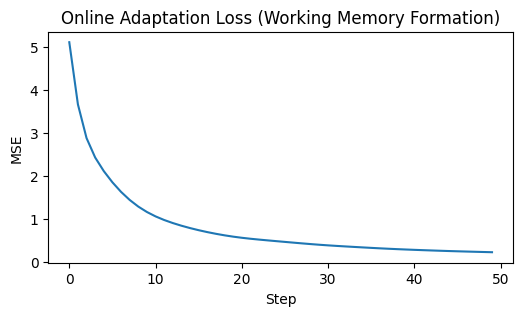

In [9]:
# 3. The Forward Pass (System 1): Perception & Surprise
# ======================================================
# We simulate a streaming scenario where the model sees frames sequentially.
# It tries to predict z_{t+1} from z_t.
# High prediction error (Surprise) indicates a "Physics Violation" or "New Event".

# Prepare Data: (Batch, Time, Dim)
features_tensor = torch.tensor(frame_features).unsqueeze(0).to(DEVICE) 
X = features_tensor[:, :-1, :] # Past
Y = features_tensor[:, 1:, :]  # Future (Target)

# Online Adaptation (Simulating Active Working Memory)
# The model adapts to the current scene dynamics (e.g., lighting, background).
optimizer = torch.optim.Adam(state_space_predictor.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

print("Running Forward Pass (Online Adaptation)...")
adaptation_steps = 50
losses = []

for step in range(adaptation_steps):
    optimizer.zero_grad()
    
    # Forward pass through the SSM
    # Note: In a real stream, we would pass state=h_t
    outputs = state_space_predictor(X)
    
    # Handle return type (Output, State) or just Output
    preds = outputs[0] if isinstance(outputs, tuple) else outputs
        
    loss = loss_fn(preds, Y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    
    if step % 10 == 0:
        print(f"Step {step}: Prediction Loss = {loss.item():.6f}")

# Compute the "Surprise Signal" (Broken Anticipation)
# ---------------------------------------------------
with torch.no_grad():
    outputs = state_space_predictor(X)
    predictions = outputs[0] if isinstance(outputs, tuple) else outputs
    
    # Calculate Euclidean Distance (L2 Norm) per time step
    # Surprise_t = || z_t - pred_t ||
    error_vec = predictions - Y
    surprise_signal = torch.norm(error_vec, dim=2).squeeze(0).cpu().numpy()

print(f"Generated Surprise Signal over {len(surprise_signal)} frames.")

# Visualize Adaptation
plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.title("Online Adaptation Loss (Working Memory Formation)")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.show()

In [10]:
# Module 3: The Boundary Discriminator
# ====================================
# "Create event boundaries from broken anticipations."
# We use an adaptive Z-score threshold to detect significant deviations.

def detect_event_boundaries(signal, window_size=10, threshold_sigma=2.5):
    """
    Detects boundaries where the signal deviates significantly from the local mean.
    
    Args:
        signal: The 'Surprise' (Prediction Error) signal.
        window_size: Size of the sliding window for local statistics.
        threshold_sigma: Lambda parameter for Z-score (e.g., 3-sigma).
    
    Returns:
        boundaries: List of indices where boundaries occur.
        means: Local mean array.
        stds: Local std array.
    """
    boundaries = []
    means = []
    stds = []
    
    # Pad signal to handle the start
    padded_signal = np.pad(signal, (window_size, 0), mode='edge')
    
    for t in range(len(signal)):
        # Calculate local statistics over the past window
        # This models the "Background Noise" of the current context
        window = padded_signal[t : t+window_size]
        mu = np.mean(window)
        sigma = np.std(window) + 1e-6 # Epsilon
        
        # Calculate Z-Score
        # (Current Surprise - Background Mean) / Background Std
        z_score = (signal[t] - mu) / sigma
        
        means.append(mu)
        stds.append(sigma)
        
        # Trigger Boundary if Surprise is statistically significant
        if z_score > threshold_sigma:
            # Simple non-maximum suppression: don't trigger consecutive frames
            if len(boundaries) == 0 or t - boundaries[-1] > window_size // 2:
                boundaries.append(t)
            
    return boundaries, np.array(means), np.array(stds)

# Detect Boundaries
boundaries, means, stds = detect_event_boundaries(surprise_signal, window_size=8, threshold_sigma=2.0)
print(f"Detected {len(boundaries)} Cognitive Events at frames: {boundaries}")

Detected 3 Cognitive Events at frames: [1, 7, 29]


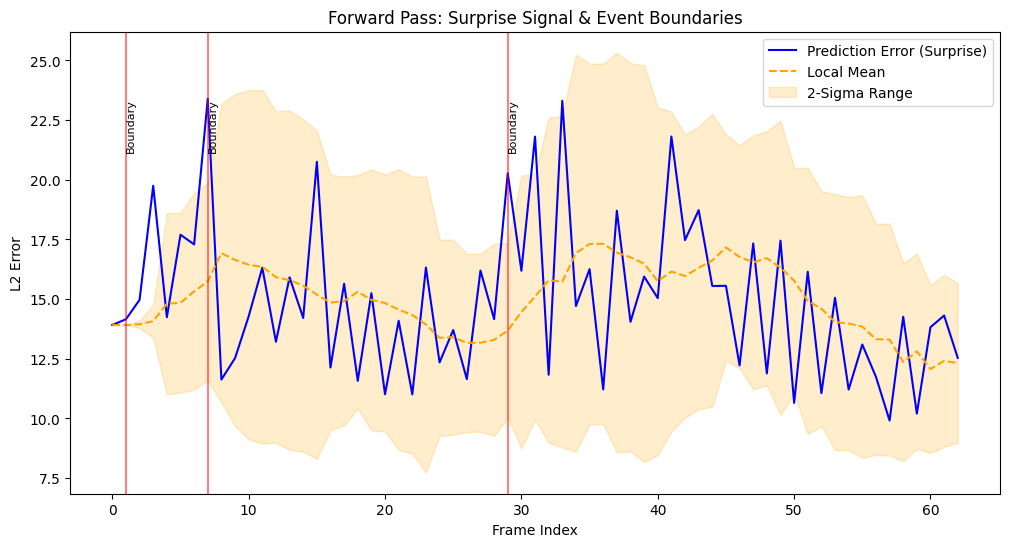

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(surprise_signal, label='Prediction Error (Surprise)', color='blue')
plt.plot(means, label='Local Mean', color='orange', linestyle='--')
plt.fill_between(range(len(surprise_signal)), means - 2*stds, means + 2*stds, color='orange', alpha=0.2, label='2-Sigma Range')

# Plot boundaries
for b in boundaries:
    plt.axvline(x=b, color='red', linestyle='-', alpha=0.5)
    plt.text(b, max(surprise_signal), 'Boundary', rotation=90, verticalalignment='top', fontsize=8)

plt.title("Forward Pass: Surprise Signal & Event Boundaries")
plt.xlabel("Frame Index")
plt.ylabel("L2 Error")
plt.legend()
plt.show()

Loaded 64 raw frames for visualization


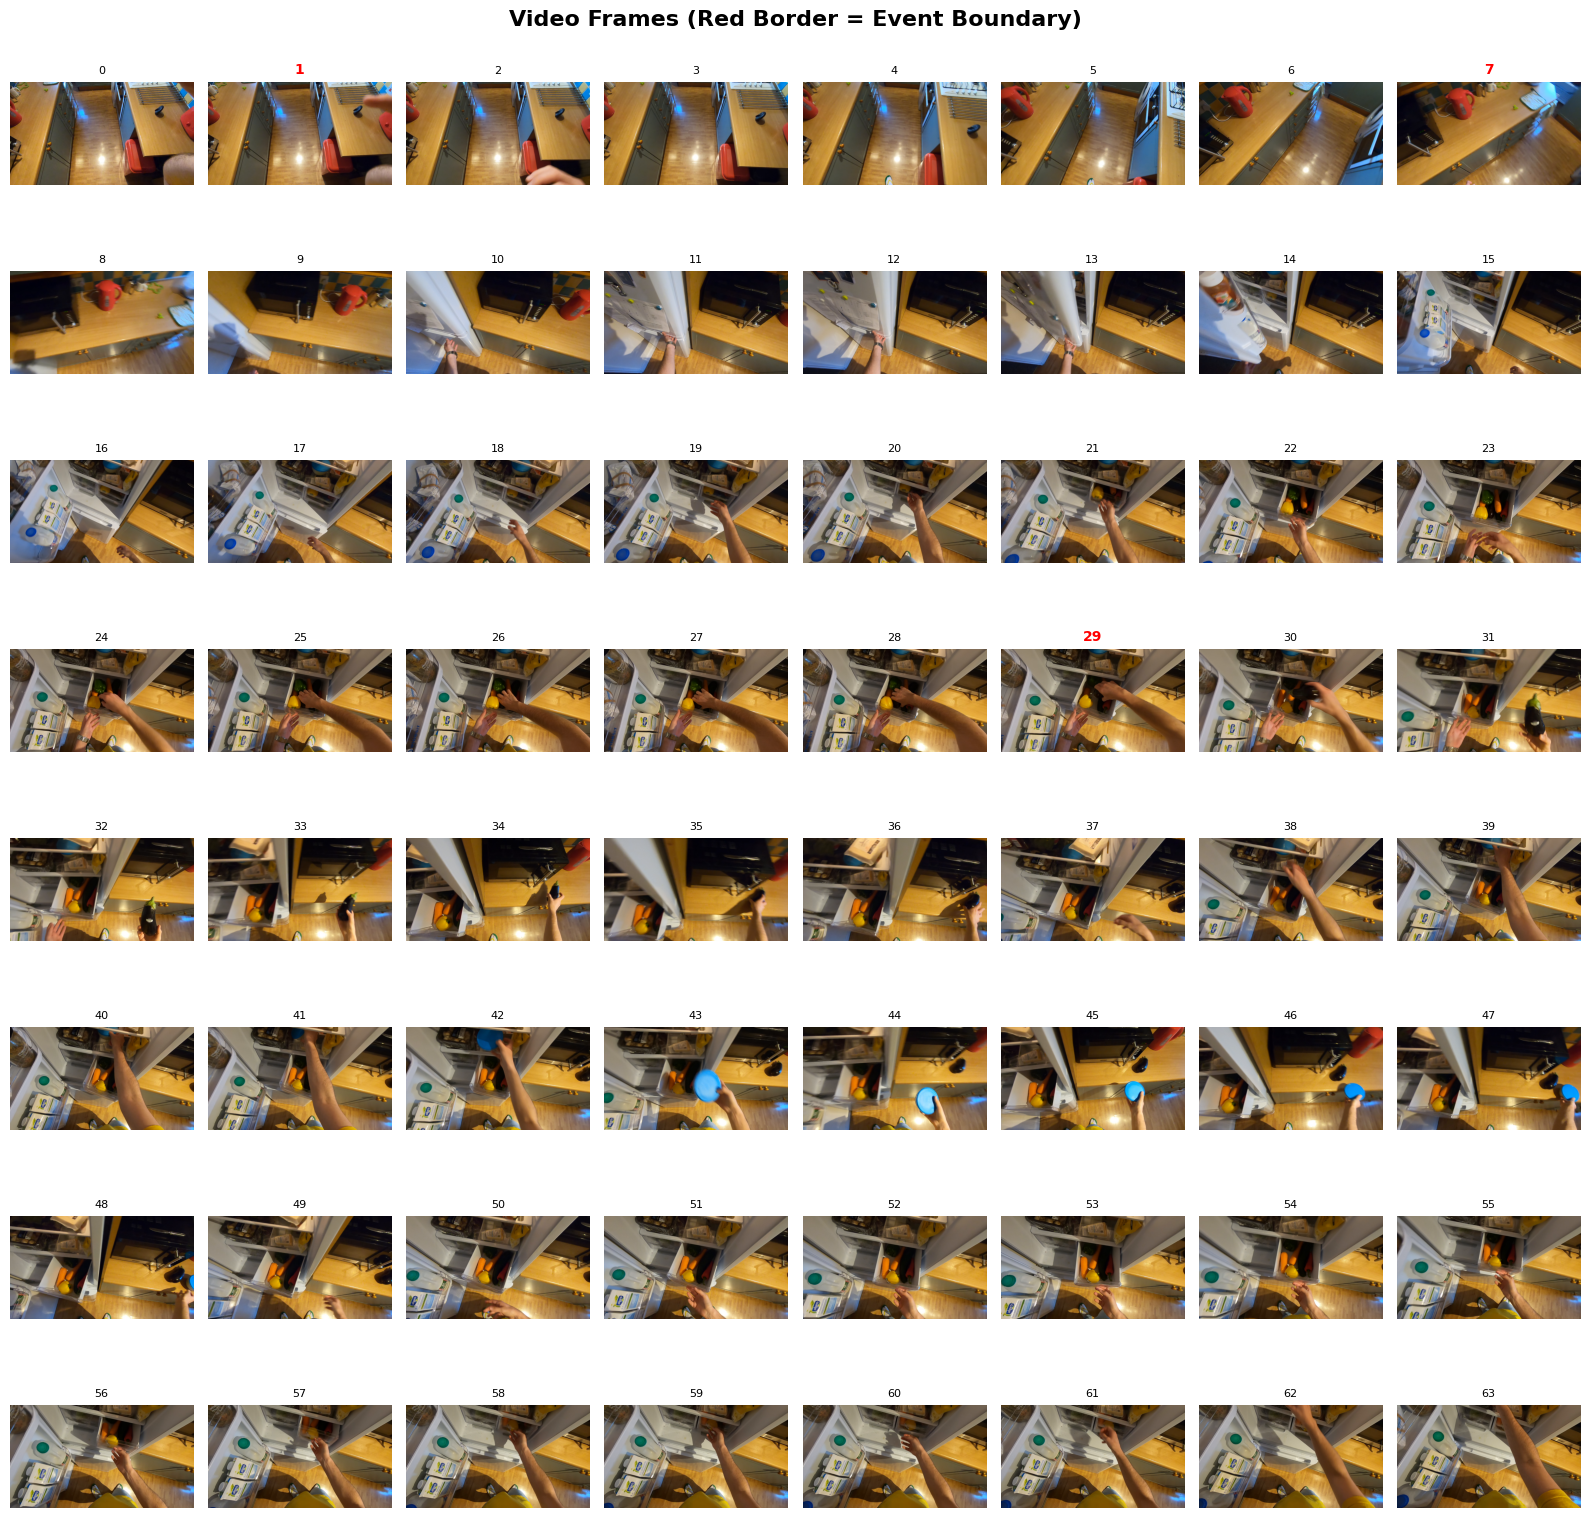

In [12]:
# Visualize All Frames with Event Boundaries
# ==========================================
# Display the 64 frames in an 8x8 grid to visually see when boundaries occur

# Load raw video frames directly (not processed by V-JEPA)
try:
    # Reload the video to get raw frames for visualization
    vr_viz = VideoDecoder(video_path)
    
    # Get the same frame indices we used earlier
    raw_frames = vr_viz.get_frames_at(indices=frame_idx).data
    
    # Convert from torch tensor to numpy: (N, C, H, W) -> (N, H, W, C)
    frames_np = raw_frames.permute(0, 2, 3, 1).cpu().numpy()
    
    # Normalize to [0, 1] for display
    frames_np = frames_np / 255.0
    frames_np = np.clip(frames_np, 0, 1)
    
    print(f"Loaded {len(frames_np)} raw frames for visualization")
    
except Exception as e:
    print(f"Error loading raw frames: {e}")
    # Fallback: use dummy data
    frames_np = np.random.rand(64, 224, 224, 3)

# Create 8x8 subplot grid
fig, axes = plt.subplots(8, 8, figsize=(16, 16))
axes = axes.flatten()

for i in range(min(len(frames_np), 64)):
    axes[i].imshow(frames_np[i])
    axes[i].axis('off')
    
    # Mark boundary frames with red border
    if i in boundaries:
        for spine in axes[i].spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(4)
            spine.set_visible(True)
        axes[i].set_title(f'{i}', color='red', fontsize=10, fontweight='bold')
    else:
        axes[i].set_title(f'{i}', fontsize=8)

# Hide any unused subplots
for i in range(len(frames_np), 64):
    axes[i].axis('off')

plt.suptitle('Video Frames (Red Border = Event Boundary)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
event_registry = []
start_idx = 0

# Add end of video as final boundary
all_boundaries = boundaries + [len(frame_features)-1]

for event_id, end_idx in enumerate(all_boundaries):
    if end_idx > start_idx:
        # 1. Extract the segment
        segment_features = frame_features[start_idx:end_idx]
        
        # 2. Get global frame indices for this event
        segment_global_frames = global_frame_indices[start_idx:end_idx]
        start_frame_global = segment_global_frames[0]
        end_frame_global = segment_global_frames[-1]
        
        # 3. Compress (Mean Pooling) -> Event Vector E_i
        event_vector = segment_features.mean(axis=0)
        
        # 4. Calculate event duration in seconds
        duration_frames = end_idx - start_idx
        duration_seconds = duration_frames / TARGET_FPS
        
        # 5. Register with GLOBAL frame indices
        event_registry.append({
            "id": event_id,
            "start_frame_local": start_idx,  # Index in frame_features array
            "end_frame_local": end_idx,
            "start_frame_global": int(start_frame_global),  # Original video frame number
            "end_frame_global": int(end_frame_global),
            "duration_frames": duration_frames,
            "duration_seconds": duration_seconds,
            "embedding": event_vector,          # Level 1: Search Vector
            "raw_latents": segment_features     # Level 2: Verification Buffer
        })
        start_idx = end_idx

print(f"Indexed {len(event_registry)} events in the Global Registry.")
print(f"\nEvent Statistics:")
print(f"  Total Duration: {sum(e['duration_seconds'] for e in event_registry):.1f} seconds")
print(f"  Avg Event Length: {np.mean([e['duration_seconds'] for e in event_registry]):.1f} seconds")
print(f"  Frame Coverage: {event_registry[0]['start_frame_global']} → {event_registry[-1]['end_frame_global']}")
print(f"\nFirst 3 Events:")
for i in range(min(3, len(event_registry))):
    e = event_registry[i]
    print(f"  Event {e['id']}: Frames {e['start_frame_global']}-{e['end_frame_global']} "
          f"({e['duration_seconds']:.1f}s, {e['duration_frames']} frames)")

Indexed 4 events in the Global Registry.

Event Statistics:
  Total Duration: 15.8 seconds
  Avg Event Length: 3.9 seconds
  Frame Coverage: 0 → 744

First 3 Events:
  Event 0: Frames 0-0 (0.2s, 1 frames)
  Event 1: Frames 12-72 (1.5s, 6 frames)
  Event 2: Frames 84-336 (5.5s, 22 frames)


In [14]:
# Load VQA Model for Backward Pass
# =================================
# We use a lightweight VQA model to verify events and answer questions about them

from transformers import AutoProcessor, Blip2ForConditionalGeneration

print("Loading BLIP-2 VQA model for visual question answering...")

try:
    # Use BLIP-2 OPT 2.7B - good balance of speed and accuracy
    vqa_model_name = "Salesforce/blip2-opt-2.7b"
    vqa_processor = AutoProcessor.from_pretrained(vqa_model_name)
    vqa_model = Blip2ForConditionalGeneration.from_pretrained(
        vqa_model_name,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
    ).to(DEVICE)
    vqa_model.eval()
    print(f"✓ Loaded VQA model: {vqa_model_name}")
    
except Exception as e:
    print(f"⚠ Error loading VQA model: {e}")
    print("  VQA will be disabled in backward pass")
    vqa_model = None
    vqa_processor = None

Loading BLIP-2 VQA model for visual question answering...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:02<00:00,  1.15s/it]


✓ Loaded VQA model: Salesforce/blip2-opt-2.7b


In [15]:
# 5. The Backward Pass (System 2): VQA-Enhanced RAG
# ==================================================
# Real Visual Question Answering on retrieved events

def ask_vqa_about_event(event_data, question, num_frames_to_sample=4):
    """
    Use VQA model to answer questions about a specific event.
    
    Args:
        event_data: Event dictionary with frame information
        question: Natural language question
        num_frames_to_sample: Number of frames to sample from the event
    
    Returns:
        VQA answer string
    """
    if vqa_model is None or vqa_processor is None:
        return "[VQA Unavailable]"
    
    try:
        # Sample frames uniformly from the event
        start_global = event_data['start_frame_global']
        end_global = event_data['end_frame_global']
        
        # Calculate which frames to sample
        event_duration = end_global - start_global
        if event_duration < num_frames_to_sample:
            sample_indices = list(range(start_global, end_global + 1))
        else:
            step = event_duration // num_frames_to_sample
            sample_indices = [start_global + i * step for i in range(num_frames_to_sample)]
        
        # Load frames from original video
        vr_vqa = VideoDecoder(video_path)
        sampled_frames = vr_vqa.get_frames_at(indices=sample_indices).data
        
        # Convert to PIL Images for VQA processor
        from PIL import Image
        pil_frames = []
        for frame_tensor in sampled_frames:
            # Convert from (C, H, W) to (H, W, C)
            frame_np = frame_tensor.permute(1, 2, 0).cpu().numpy()
            frame_np = np.clip(frame_np, 0, 255).astype(np.uint8)
            pil_frames.append(Image.fromarray(frame_np))
        
        # Query VQA model on each frame (BLIP-2 processes single images)
        answers = []
        for pil_frame in pil_frames:
            inputs = vqa_processor(images=pil_frame, text=question, return_tensors="pt").to(DEVICE)
            
            with torch.no_grad():
                generated_ids = vqa_model.generate(**inputs, max_new_tokens=50)
            
            answer = vqa_processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
            answers.append(answer)
        
        # Aggregate answers (simple majority vote or most confident)
        # For simplicity, return the first non-empty answer or the most common
        from collections import Counter
        answer_counts = Counter(answers)
        most_common_answer = answer_counts.most_common(1)[0][0] if answer_counts else "Unknown"
        
        return most_common_answer
        
    except Exception as e:
        print(f"    ⚠ VQA Error: {e}")
        return "[VQA Error]"


# Enhanced RAG Pipeline with Real VQA
def backward_pass_vqa_rag(query, registry, top_k=3):
    """
    VQA-Enhanced Retrieval-Augmented Generation for dietary monitoring.
    
    Args:
        query: Natural language question
        registry: Event registry from forward pass
        top_k: Number of candidates to retrieve
    
    Returns:
        Dictionary with analysis results
    """
    print(f"\n{'='*70}")
    print(f"VQA-ENHANCED RAG PIPELINE")
    print(f"Query: '{query}'")
    print(f"{'='*70}\n")
    
    if not registry:
        return {"error": "No events in registry"}
    
    # Step 1: Retrieval (Level 1 - Coarse Filter)
    # ============================================
    print("STEP 1: Event Retrieval (Surprise-Based Filtering)")
    print("-" * 70)
    
    candidates = []
    for event in registry:
        # Calculate multiple relevance signals
        latents = event['raw_latents']
        
        # Signal 1: Temporal Variance (High variance = Complex interaction)
        temporal_var = np.var(latents, axis=0).mean()
        
        # Signal 2: Magnitude Change (Large changes = New object interaction)
        if len(latents) > 1:
            frame_diffs = np.diff(latents, axis=0)
            magnitude_change = np.linalg.norm(frame_diffs, axis=1).mean()
        else:
            magnitude_change = 0
        
        # Signal 3: Duration (Eating events typically 2-10 seconds)
        duration_score = 1.0 if 2.0 <= event['duration_seconds'] <= 10.0 else 0.3
        
        # Combined relevance score
        relevance = (
            0.4 * temporal_var + 
            0.4 * magnitude_change + 
            0.2 * duration_score
        )
        
        candidates.append({
            **event,
            'relevance_score': relevance,
            'temporal_var': temporal_var,
            'magnitude_change': magnitude_change
        })
    
    # Sort by relevance and take top-k
    candidates = sorted(candidates, key=lambda x: x['relevance_score'], reverse=True)[:top_k]
    
    print(f"Retrieved Top-{top_k} candidates based on surprise signals:")
    for c in candidates:
        print(f"  Event {c['id']:3d}: Relevance={c['relevance_score']:.4f}, "
              f"Frames {c['start_frame_global']}-{c['end_frame_global']}, "
              f"Duration={c['duration_seconds']:.1f}s")
    
    # Step 2: VQA-Based Verification
    # ===============================
    print(f"\nSTEP 2: VQA Verification")
    print("-" * 70)
    
    verified_events = []
    
    # Ask multiple verification questions for each candidate
    verification_questions = [
        "Is there food in this image?",
        "Is someone eating or holding food?",
        "What is the person doing?"
    ]
    
    for candidate in candidates:
        print(f"\nEvent {candidate['id']} (Frames {candidate['start_frame_global']}-{candidate['end_frame_global']}):")
        
        vqa_results = {}
        confidence_score = 0
        
        for vq in verification_questions:
            answer = ask_vqa_about_event(candidate, vq, num_frames_to_sample=3)
            vqa_results[vq] = answer
            print(f"  Q: {vq}")
            print(f"  A: {answer}")
            
            # Simple confidence heuristics
            answer_lower = answer.lower()
            if vq == "Is there food in this image?":
                if 'yes' in answer_lower or 'food' in answer_lower:
                    confidence_score += 2
            elif vq == "Is someone eating or holding food?":
                if 'yes' in answer_lower or 'eat' in answer_lower or 'hold' in answer_lower:
                    confidence_score += 3
            elif vq == "What is the person doing?":
                if any(word in answer_lower for word in ['eat', 'food', 'cook', 'prepar', 'hold']):
                    confidence_score += 2
        
        verified_events.append({
            **candidate,
            'vqa_results': vqa_results,
            'confidence_score': confidence_score
        })
        
        print(f"  → Confidence Score: {confidence_score}/7")
    
    # Select best verified event
    if not verified_events:
        return {"error": "No events to verify"}
    
    verified_events = sorted(verified_events, key=lambda x: x['confidence_score'], reverse=True)
    target_event = verified_events[0]
    
    print(f"\n✓ Selected Event {target_event['id']} with confidence {target_event['confidence_score']}/7")
    
    # Step 3: Detailed Analysis with VQA
    # ===================================
    print(f"\nSTEP 3: Detailed VQA Analysis")
    print("-" * 70)
    
    # Ask detailed questions about the selected event
    detailed_questions = [
        "What type of food is visible?",
        "How much food is there?",
        "Describe what you see in detail"
    ]
    
    detailed_answers = {}
    for dq in detailed_questions:
        answer = ask_vqa_about_event(target_event, dq, num_frames_to_sample=4)
        detailed_answers[dq] = answer
        print(f"Q: {dq}")
        print(f"A: {answer}\n")
    
    # Step 4: Synthesis
    # =================
    print(f"STEP 4: Result Synthesis")
    print("-" * 70)
    
    # Estimate calories based on VQA responses
    # (In production: use food database lookup)
    estimated_calories = 150 + (target_event['duration_seconds'] * 20)
    confidence_pct = min(100, (target_event['confidence_score'] / 7.0) * 100)
    
    result = {
        "event_id": target_event['id'],
        "frame_range": (target_event['start_frame_global'], target_event['end_frame_global']),
        "duration_seconds": target_event['duration_seconds'],
        "vqa_verification": target_event['vqa_results'],
        "vqa_detailed": detailed_answers,
        "estimated_calories": estimated_calories,
        "confidence": confidence_pct,
        "relevance_score": target_event['relevance_score']
    }
    
    return result


# Execute VQA-Enhanced RAG
print("Starting VQA-Enhanced Backward Pass...")
result = backward_pass_vqa_rag("How many calories did I eat?", event_registry, top_k=3)

# Display Final Results
print("\n" + "="*70)
print("FINAL REPORT")
print("="*70)

if "error" in result:
    print(f"❌ {result['error']}")
else:
    print(f"\n✓ DETECTED EATING EVENT")
    print(f"  Event ID: {result['event_id']}")
    print(f"  Video Frames: {result['frame_range'][0]} → {result['frame_range'][1]}")
    print(f"  Duration: {result['duration_seconds']:.1f} seconds")
    print(f"  Estimated Calories: {result['estimated_calories']:.0f} kcal")
    print(f"  Confidence: {result['confidence']:.0f}%")
    
    print(f"\n  VQA VERIFICATION RESULTS:")
    for q, a in result['vqa_verification'].items():
        print(f"    • {q}")
        print(f"      → {a}")
    
    print(f"\n  VQA DETAILED ANALYSIS:")
    for q, a in result['vqa_detailed'].items():
        print(f"    • {q}")
        print(f"      → {a}")

Starting VQA-Enhanced Backward Pass...

VQA-ENHANCED RAG PIPELINE
Query: 'How many calories did I eat?'

STEP 1: Event Retrieval (Surprise-Based Filtering)
----------------------------------------------------------------------
Retrieved Top-3 candidates based on surprise signals:
  Event   1: Relevance=18.6570, Frames 12-72, Duration=1.5s
  Event   3: Relevance=16.5126, Frames 348-744, Duration=8.5s
  Event   2: Relevance=16.2075, Frames 84-336, Duration=5.5s

STEP 2: VQA Verification
----------------------------------------------------------------------

Event 1 (Frames 12-72):
  Q: Is there food in this image?
  A: Is there food in this image?
  Q: Is someone eating or holding food?
  A: Is someone eating or holding food?
  Q: What is the person doing?
  A: What is the person doing?
  → Confidence Score: 5/7

Event 3 (Frames 348-744):
  Q: Is there food in this image?
  A: Is there food in this image?
  Q: Is someone eating or holding food?
  A: Is someone eating or holding food?
  Q